3.**IPL DATA ANALYSIS**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("IPL.csv")
print(df.head())
print(df.columns)

In [ ]:
df.dropna(subset=['batter', 'bowler', 'batsman_runs'], inplace=True)

In [ ]:
top_batters = (
    df.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop Batsmen:")
print(top_batters)


Top Batsmen:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


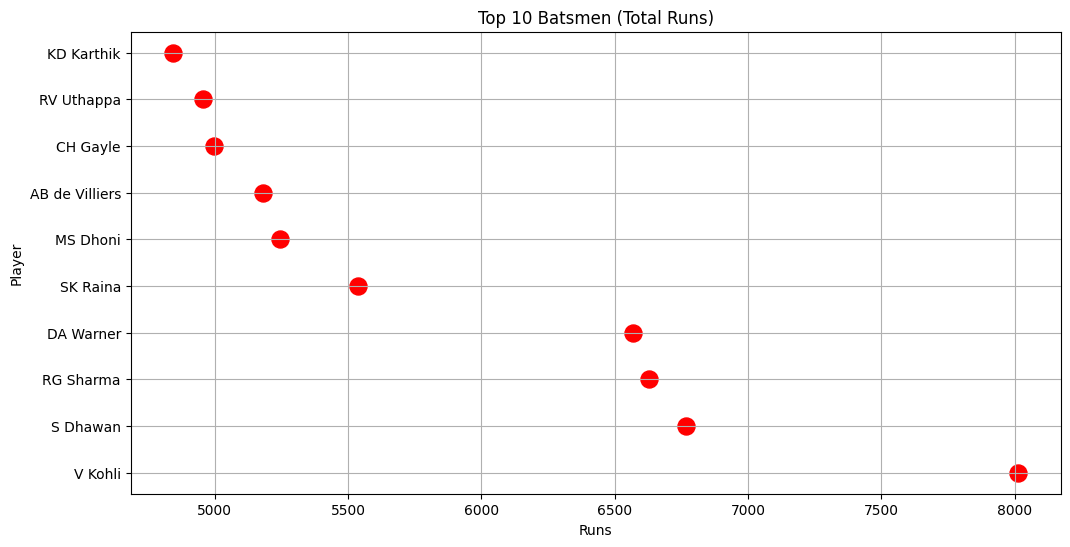

In [16]:
print("\nTop Batsmen:")
print(top_batters)

plt.figure(figsize=(12,6))
plt.scatter(
    top_batters.values,
    top_batters.index,
    color='red',
    s=150
)
plt.title("Top 10 Batsmen (Total Runs)")
plt.xlabel("Runs")
plt.ylabel("Player")
plt.grid(True)
plt.show()

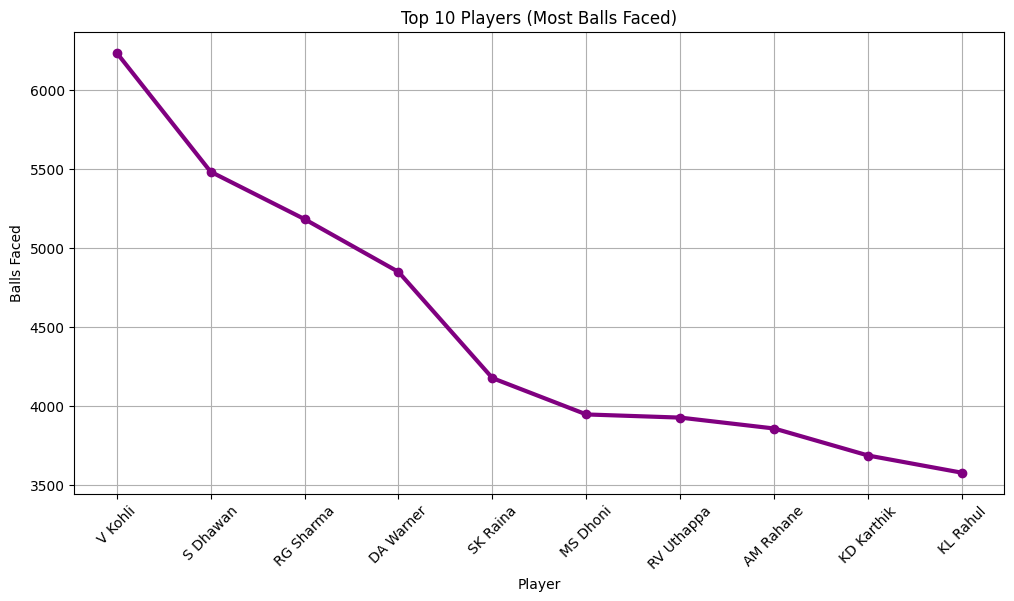

In [17]:
balls_faced = df['batter'].value_counts().head(10)
plt.figure(figsize=(12,6))
plt.plot(
    balls_faced.index,
    balls_faced.values,
    marker='o',
    color='purple',
    linewidth=3
)
plt.title("Top 10 Players (Most Balls Faced)")
plt.xlabel("Player")
plt.ylabel("Balls Faced")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Top Bowlers:
bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64


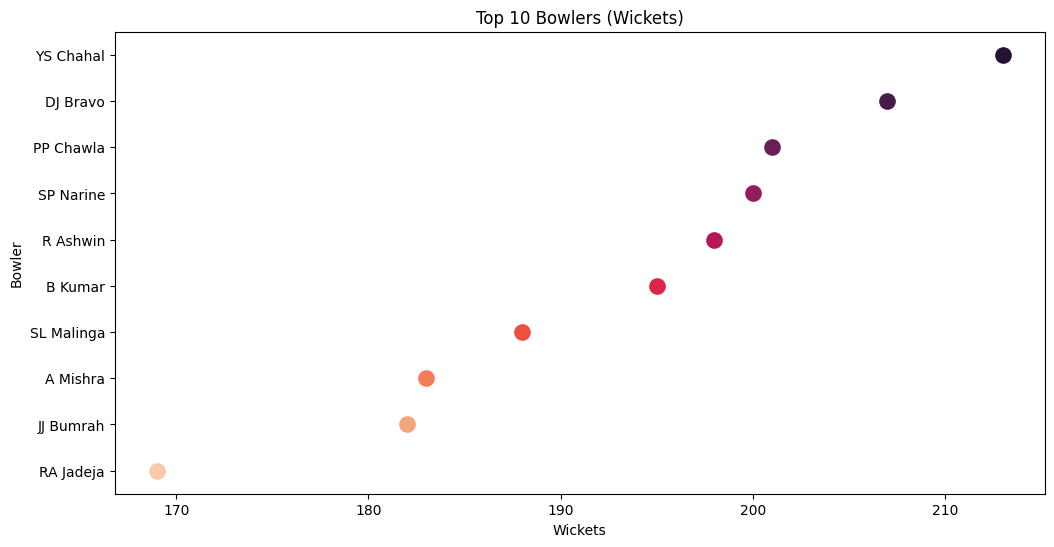

In [18]:
wickets_df = df[df['is_wicket'] == 1]
top_bowlers = wickets_df['bowler'].value_counts().head(10)
print("\nTop Bowlers:")
print(top_bowlers)

plt.figure(figsize=(12,6))
sns.stripplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    hue=top_bowlers.index, # Assign y to hue to resolve FutureWarning
    palette="rocket",
    size=12,
    legend=False # Set legend to False as hue is used for color mapping already
)
plt.title("Top 10 Bowlers (Wickets)")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()


Top Bowlers:
bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64


/tmp/ipykernel_2843/1816795665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


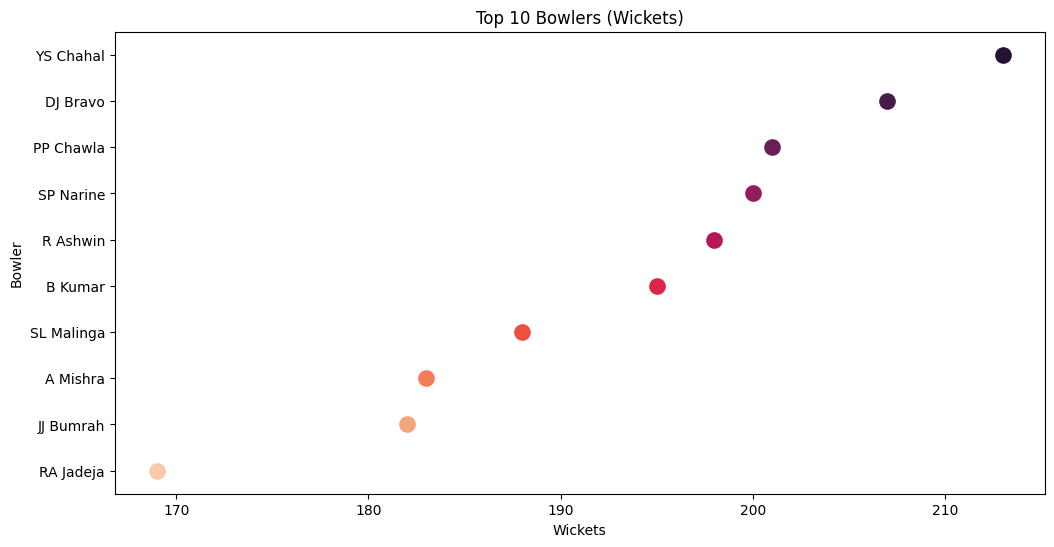

In [19]:
wickets_df = df[df['is_wicket'] == 1]
top_bowlers = wickets_df['bowler'].value_counts().head(10)
print("\nTop Bowlers:")
print(top_bowlers)

plt.figure(figsize=(12,6))
sns.stripplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    size=12,
    palette="rocket"
)
plt.title("Top 10 Bowlers (Wickets)")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()

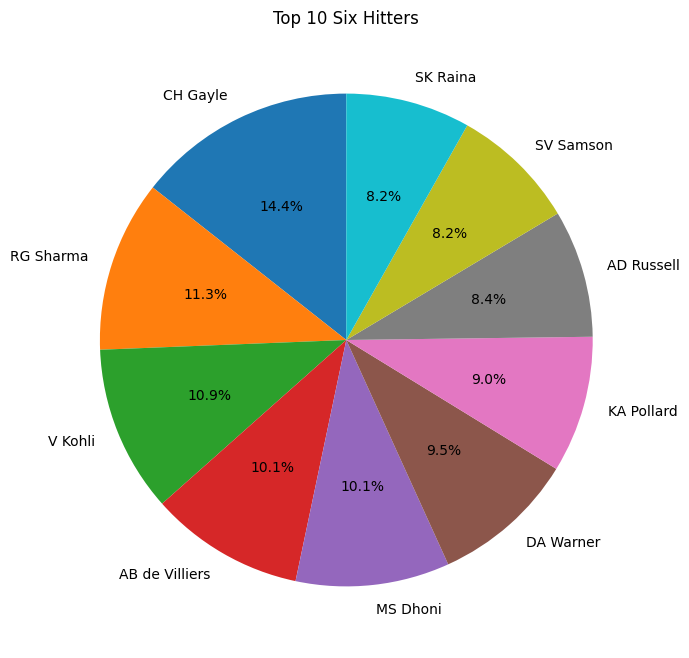

In [20]:
sixes = df[df['batsman_runs'] == 6]

top_six_hitters = sixes['batter'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_six_hitters.values,
    labels=top_six_hitters.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 Six Hitters")

plt.show()

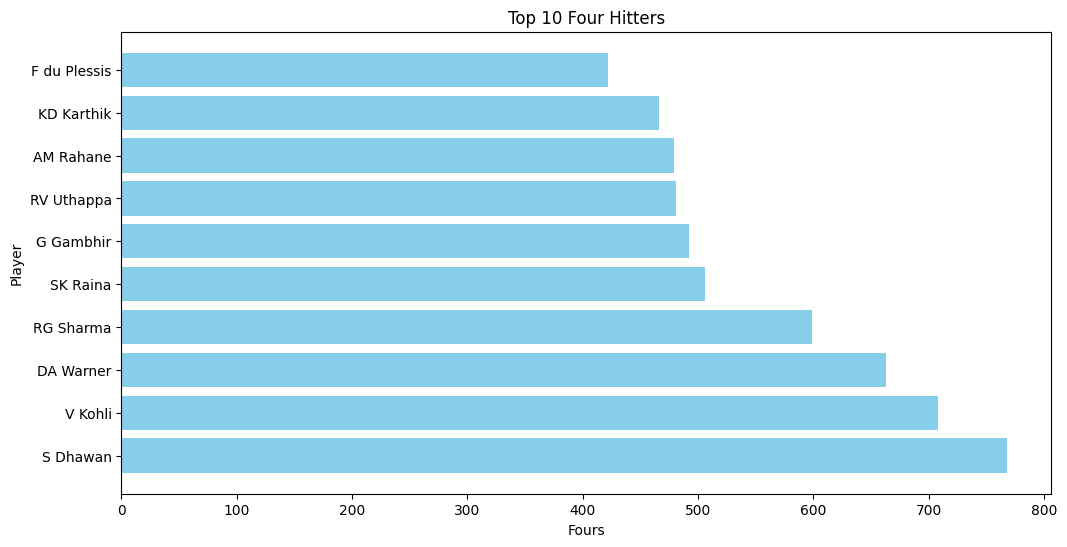

In [21]:
fours = df[df['batsman_runs'] == 4]

top_four_hitters = fours['batter'].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_four_hitters.index,
    top_four_hitters.values,
    color='skyblue'
)
plt.title("Top 10 Four Hitters")
plt.xlabel("Fours")
plt.ylabel("Player")
plt.show()

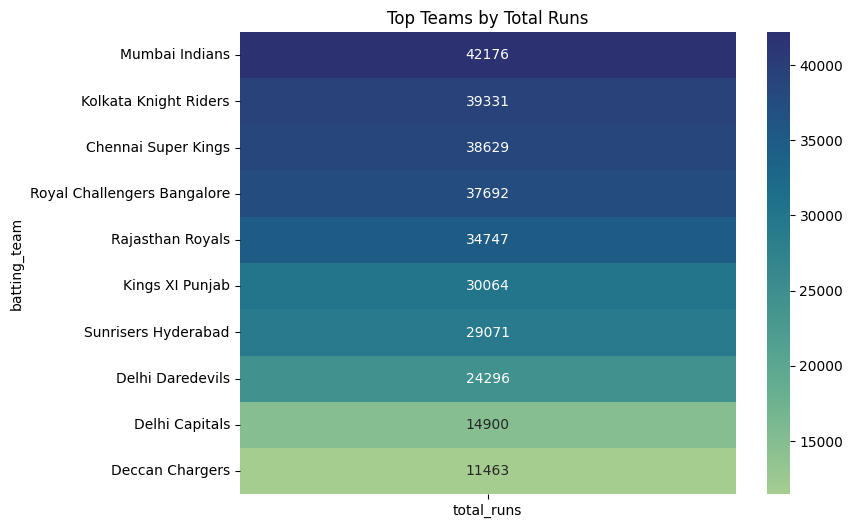

In [22]:
team_runs = (
    df.groupby('batting_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
team_runs_df = pd.DataFrame(team_runs)
plt.figure(figsize=(8,6))
sns.heatmap(
    team_runs_df,
    annot=True,
    cmap='crest',
    fmt='g'
)
plt.title("Top Teams by Total Runs")
plt.show()

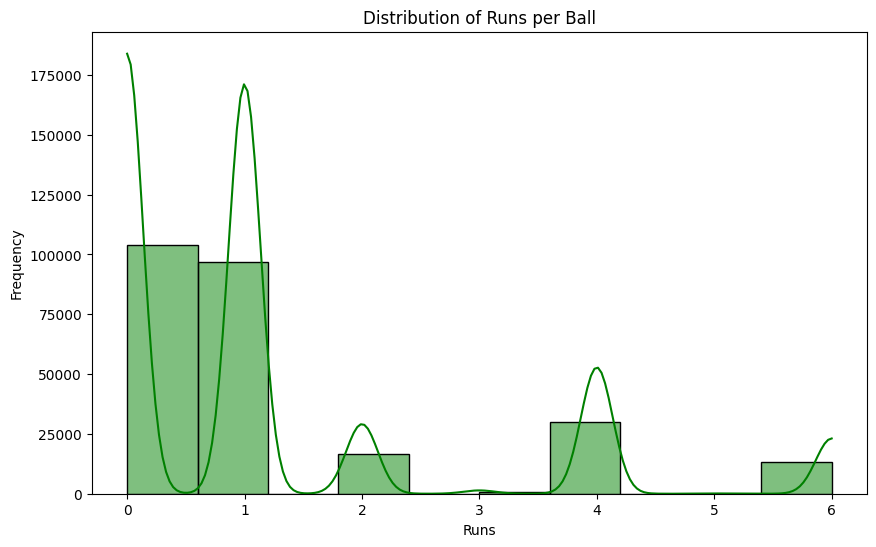

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(
    df['batsman_runs'],
    bins=10,
    kde=True,
    color='green'
)
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

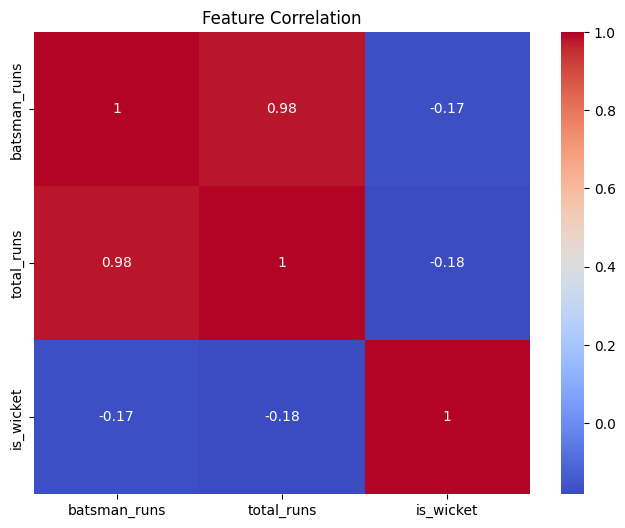


Analysis Completed Successfully!


In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['batsman_runs', 'total_runs', 'is_wicket']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation")
plt.show()
df.to_csv("cleaned_deliveries.csv", index=False)
print("\nAnalysis Completed Successfully!")